Cell 1 — Import libraries + paths.py

In [24]:
# ============================================================
# CELL 1: Import libraries + project paths
# ============================================================

from pathlib import Path
import sys
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 120


# =====================================================
# Import project paths
# =====================================================
# Nếu notebook nằm trong /notebooks, thêm PROJECT_ROOT vào sys.path
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.path import (
    DATA_PREPROCESSED_FILE, 
    MODELS_DIR, 
    REPORTS_DIR, 
    FIGURES_DIR,
    check_and_create_directories
)


# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

MODEL_OUTPUT_DIR = Path(MODELS_DIR)
TABLE_OUTPUT_DIR = Path(REPORTS_DIR) / "modeling"
FIGURE_OUTPUT_DIR = Path(FIGURES_DIR) / "modeling"

MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PREPROCESSED_FILE:", DATA_PREPROCESSED_FILE)
print("MODEL_OUTPUT_DIR:", MODEL_OUTPUT_DIR)
print("TABLE_OUTPUT_DIR:", TABLE_OUTPUT_DIR)
print("FIGURE_OUTPUT_DIR:", FIGURE_OUTPUT_DIR)

PROJECT_ROOT: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn
DATA_PREPROCESSED_FILE: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\data\preprocessed_data\preprocessed_data.csv
MODEL_OUTPUT_DIR: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\models
TABLE_OUTPUT_DIR: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling
FIGURE_OUTPUT_DIR: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling


Cell 2 — Load dataset + kiểm tra nhanh

In [25]:
# ============================================================
# CELL 2: Load cleaned input dataset
# ============================================================

df = pd.read_csv(DATA_PREPROCESSED_FILE)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nFirst 5 rows:")
print(df.head().to_string())

Dataset loaded successfully.
Shape: (7043, 16)

Columns:
['ID', 'Churn', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Tenure', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges']

Data types:
ID                   object
Churn                 int64
SeniorCitizen         int64
Partner               int64
Dependents           object
InternetService      object
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
Tenure                int64
Contract              int64
PaymentMethod        object
PaperlessBilling      int64
MonthlyCharges      float64
TotalCharges        float64
dtype: object

Missing values:
ID                  0
Churn               0
SeniorCitizen       0
Partner             0
Dependents          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport   

Cell 3 — Basic validation trước khi train

In [26]:
# ============================================================
# CELL 3: Basic validation
# ============================================================

required_columns = [
    "ID",
    "Churn",
    "Tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Contract",
]

missing_required_columns = [col for col in required_columns if col not in df.columns]

if missing_required_columns:
    raise ValueError(f"Missing required columns: {missing_required_columns}")

print("Required columns check: PASSED")

print("\nChurn value counts:")
print(df["Churn"].value_counts(dropna=False).to_string())

print("\nChurn ratio:")
print(df["Churn"].value_counts(normalize=True).to_string())

print("\nContract unique values:")
print(sorted(df["Contract"].dropna().unique()))

Required columns check: PASSED

Churn value counts:
Churn
0    5174
1    1869

Churn ratio:
Churn
0    0.73463
1    0.26537

Contract unique values:
[np.int64(1), np.int64(12), np.int64(24)]


Cell 4 — Define X/y + Train/Test split

In [27]:
# ============================================================
# CELL 4: Define X/y and train-test split
# ============================================================

RANDOM_STATE = 42
TEST_SIZE = 0.20

# Keep ID separately for prediction output
customer_id = df["ID"].copy()

# Drop ID and target from features
X = df.drop(columns=["ID", "Churn"])
y = df["Churn"].astype(int)

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X,
    y,
    customer_id,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train/Test split completed.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).to_string())

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).to_string())

Train/Test split completed.
X_train shape: (5634, 14)
X_test shape: (1409, 14)

Train target distribution:
Churn
0    0.734647
1    0.265353

Test target distribution:
Churn
0    0.734564
1    0.265436


Cell 5 — Feature engineering sau split

In [28]:
# ============================================================
# CELL 5: Train-aware feature engineering
# ============================================================

def create_features_after_split(X_train_input, X_test_input):
    """
    Create engineered features after train-test split.

    Important:
    - monthly_charges_ratio uses mean MonthlyCharges from X_train only.
    - The same train mean is reused for X_test.
    """

    X_train_fe = X_train_input.copy()
    X_test_fe = X_test_input.copy()

    # --------------------------------------------------------
    # Contract_Label
    # --------------------------------------------------------

    contract_mapping = {
        1: "Month-to-month",
        12: "One year",
        24: "Two year",
    }

    X_train_fe["Contract_Label"] = X_train_fe["Contract"].map(contract_mapping)
    X_test_fe["Contract_Label"] = X_test_fe["Contract"].map(contract_mapping)

    # If any unexpected value appears
    X_train_fe["Contract_Label"] = X_train_fe["Contract_Label"].fillna("Unknown")
    X_test_fe["Contract_Label"] = X_test_fe["Contract_Label"].fillna("Unknown")

    # Drop numeric Contract to avoid duplicate information
    X_train_fe = X_train_fe.drop(columns=["Contract"])
    X_test_fe = X_test_fe.drop(columns=["Contract"])

    # --------------------------------------------------------
    # tenure_group
    # --------------------------------------------------------

    tenure_bins = [0, 12, 24, 36, 48, 60, 72]
    tenure_labels = [
        "0-12 months",
        "13-24 months",
        "25-36 months",
        "37-48 months",
        "49-60 months",
        "61-72 months",
    ]

    X_train_fe["tenure_group"] = pd.cut(
        X_train_fe["Tenure"],
        bins=tenure_bins,
        labels=tenure_labels,
        include_lowest=True
    ).astype(str)

    X_test_fe["tenure_group"] = pd.cut(
        X_test_fe["Tenure"],
        bins=tenure_bins,
        labels=tenure_labels,
        include_lowest=True
    ).astype(str)

    # --------------------------------------------------------
    # service_diversity
    # --------------------------------------------------------

    service_columns = [
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
    ]

    available_service_columns = [
        col for col in service_columns
        if col in X_train_fe.columns
    ]

    X_train_fe["service_diversity"] = X_train_fe[available_service_columns].sum(axis=1)
    X_test_fe["service_diversity"] = X_test_fe[available_service_columns].sum(axis=1)

    # --------------------------------------------------------
    # monthly_charges_ratio
    # --------------------------------------------------------

    train_monthly_charges_mean = X_train_fe["MonthlyCharges"].mean()

    X_train_fe["monthly_charges_ratio"] = (
        X_train_fe["MonthlyCharges"] / train_monthly_charges_mean
    )

    X_test_fe["monthly_charges_ratio"] = (
        X_test_fe["MonthlyCharges"] / train_monthly_charges_mean
    )

    # --------------------------------------------------------
    # is_paperless_electronic
    # --------------------------------------------------------

    if "PaymentMethod" in X_train_fe.columns and "PaperlessBilling" in X_train_fe.columns:
        X_train_fe["is_paperless_electronic"] = (
            (X_train_fe["PaperlessBilling"] == 1)
            & (X_train_fe["PaymentMethod"].astype(str).str.contains("Electronic", case=False, na=False))
        ).astype(int)

        X_test_fe["is_paperless_electronic"] = (
            (X_test_fe["PaperlessBilling"] == 1)
            & (X_test_fe["PaymentMethod"].astype(str).str.contains("Electronic", case=False, na=False))
        ).astype(int)
    else:
        X_train_fe["is_paperless_electronic"] = 0
        X_test_fe["is_paperless_electronic"] = 0

    return X_train_fe, X_test_fe, train_monthly_charges_mean


X_train_fe, X_test_fe, train_monthly_charges_mean = create_features_after_split(X_train, X_test)

print("Feature engineering completed.")
print("Train MonthlyCharges mean used for monthly_charges_ratio:", train_monthly_charges_mean)

print("\nX_train_fe columns:")
print(X_train_fe.columns.tolist())

print("\nFirst 5 rows after feature engineering:")
print(X_train_fe.head().to_string())

Feature engineering completed.
Train MonthlyCharges mean used for monthly_charges_ratio: 64.92996095136671

X_train_fe columns:
['SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Tenure', 'PaymentMethod', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Contract_Label', 'tenure_group', 'service_diversity', 'monthly_charges_ratio', 'is_paperless_electronic']

First 5 rows after feature engineering:
      SeniorCitizen  Partner Dependents InternetService  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  Tenure            PaymentMethod  PaperlessBilling  MonthlyCharges  TotalCharges  Contract_Label  tenure_group  service_diversity  monthly_charges_ratio  is_paperless_electronic
4626              0        0         No             DSL               0             0                 1            0      35         Electronic check                 0           49.20       1701.65  Month-to-month  25

Cell 6 — Logistic Regression preprocessing

In [29]:
# ============================================================
# CELL 6: Logistic Regression preprocessing
# ============================================================

def apply_iqr_capping(X_train_input, X_test_input, columns):
    """
    Fit IQR bounds on X_train only.
    Apply the same bounds to X_train and X_test.
    """

    X_train_capped = X_train_input.copy()
    X_test_capped = X_test_input.copy()

    cap_info = []

    for col in columns:
        if col not in X_train_capped.columns:
            continue

        q1 = X_train_capped[col].quantile(0.25)
        q3 = X_train_capped[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        X_train_capped[col] = X_train_capped[col].clip(lower_bound, upper_bound)
        X_test_capped[col] = X_test_capped[col].clip(lower_bound, upper_bound)

        cap_info.append({
            "feature": col,
            "q1_train": q1,
            "q3_train": q3,
            "iqr_train": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
        })

    cap_info_df = pd.DataFrame(cap_info)

    return X_train_capped, X_test_capped, cap_info_df


# ------------------------------------------------------------
# IQR capping for Logistic Regression branch
# ------------------------------------------------------------

capping_columns = ["Tenure", "MonthlyCharges"]

X_train_logreg, X_test_logreg, cap_info_df = apply_iqr_capping(
    X_train_fe,
    X_test_fe,
    capping_columns
)

print("IQR capping completed.")
print("\nCapping info:")
print(cap_info_df.to_string(index=False))


# ------------------------------------------------------------
# log1p transform TotalCharges for Logistic Regression branch
# ------------------------------------------------------------

X_train_logreg["TotalCharges_Log"] = np.log1p(X_train_logreg["TotalCharges"])
X_test_logreg["TotalCharges_Log"] = np.log1p(X_test_logreg["TotalCharges"])

X_train_logreg = X_train_logreg.drop(columns=["TotalCharges"])
X_test_logreg = X_test_logreg.drop(columns=["TotalCharges"])

print("\nLog transform completed: TotalCharges -> TotalCharges_Log")
print("X_train_logreg shape:", X_train_logreg.shape)
print("X_test_logreg shape:", X_test_logreg.shape)

IQR capping completed.

Capping info:
       feature  q1_train  q3_train  iqr_train  lower_bound  upper_bound
        Tenure    9.0000      55.0    46.0000    -60.00000    124.00000
MonthlyCharges   35.6625      90.0    54.3375    -45.84375    171.50625

Log transform completed: TotalCharges -> TotalCharges_Log
X_train_logreg shape: (5634, 18)
X_test_logreg shape: (1409, 18)


Cell 7 — Define feature lists

In [30]:
# ============================================================
# CELL 7: Define numeric and categorical features
# ============================================================

binary_numeric_features = [
    "SeniorCitizen",
    "Partner",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "PaperlessBilling",
]

continuous_numeric_features = [
    "Tenure",
    "MonthlyCharges",
    "TotalCharges_Log",
    "service_diversity",
    "monthly_charges_ratio",
    "is_paperless_electronic",
]

categorical_features = [
    "Dependents",
    "InternetService",
    "PaymentMethod",
    "Contract_Label",
    "tenure_group",
]

numeric_features = binary_numeric_features + continuous_numeric_features

# Keep only available columns to avoid notebook breaking
numeric_features = [col for col in numeric_features if col in X_train_logreg.columns]
categorical_features = [col for col in categorical_features if col in X_train_logreg.columns]

selected_features = numeric_features + categorical_features

X_train_model = X_train_logreg[selected_features].copy()
X_test_model = X_test_logreg[selected_features].copy()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nSelected features:")
print(selected_features)

print("\nX_train_model shape:", X_train_model.shape)
print("X_test_model shape:", X_test_model.shape)

print("\nSample X_train_model:")
print(X_train_model.head().to_string())

Numeric features:
['SeniorCitizen', 'Partner', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'PaperlessBilling', 'Tenure', 'MonthlyCharges', 'TotalCharges_Log', 'service_diversity', 'monthly_charges_ratio', 'is_paperless_electronic']

Categorical features:
['Dependents', 'InternetService', 'PaymentMethod', 'Contract_Label', 'tenure_group']

Selected features:
['SeniorCitizen', 'Partner', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'PaperlessBilling', 'Tenure', 'MonthlyCharges', 'TotalCharges_Log', 'service_diversity', 'monthly_charges_ratio', 'is_paperless_electronic', 'Dependents', 'InternetService', 'PaymentMethod', 'Contract_Label', 'tenure_group']

X_train_model shape: (5634, 18)
X_test_model shape: (1409, 18)

Sample X_train_model:
      SeniorCitizen  Partner  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  PaperlessBilling  Tenure  MonthlyCharges  TotalCharges_Log  service_diversity  monthly_charges_ratio  is_paperless

Cell 8 — Build and train Logistic Regression

In [31]:
# ============================================================
# CELL 8: Build and train Logistic Regression
# ============================================================

def create_one_hot_encoder():
    """
    Compatible with both newer and older sklearn versions.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", create_one_hot_encoder())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

logreg_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", logreg_model)
    ]
)

logreg_pipeline.fit(X_train_model, y_train)

print("Logistic Regression training completed.")
print("\nModel parameters:")
print(logreg_pipeline.named_steps["model"])

Logistic Regression training completed.

Model parameters:
LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


Cell 9 — Evaluate Logistic Regression at threshold 0.50

In [32]:
# ============================================================
# CELL 9: Evaluate Logistic Regression at threshold 0.50
# ============================================================

DEFAULT_THRESHOLD = 0.50

y_test_proba = logreg_pipeline.predict_proba(X_test_model)[:, 1]
y_test_pred = (y_test_proba >= DEFAULT_THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

logreg_metrics_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Threshold": DEFAULT_THRESHOLD,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, zero_division=0),
        "Recall": recall_score(y_test, y_test_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_test_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_test_proba),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }
])

logreg_metrics_path = TABLE_OUTPUT_DIR / "logreg_metrics.csv"
logreg_metrics_df.to_csv(logreg_metrics_path, index=False)

print("Saved:", logreg_metrics_path)
print("\nlogreg_metrics.csv:")
print(logreg_metrics_df.to_string(index=False))

print("\nClassification report:")
print(classification_report(y_test, y_test_pred, target_names=["Non-Churn", "Churn"], zero_division=0))

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\logreg_metrics.csv

logreg_metrics.csv:
              Model  Threshold  Accuracy  Precision   Recall  F1-score  ROC-AUC  TN  FP  FN  TP
Logistic Regression        0.5  0.738822   0.505102 0.794118  0.617464 0.851551 744 291  77 297

Classification report:
              precision    recall  f1-score   support

   Non-Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



Cell 10 — Threshold Sensitivity Analysis

In [33]:
# ============================================================
# CELL 10: Threshold Sensitivity Analysis
# ============================================================

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]

threshold_rows = []

for threshold in thresholds:
    y_pred_threshold = (y_test_proba >= threshold).astype(int)

    threshold_rows.append({
        "Model": "Logistic Regression",
        "Threshold": threshold,
        "Accuracy" : accuracy_score(y_test,y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_threshold, zero_division=0),
        "ROC_AUC" : roc_auc_score(y_test,y_pred_threshold)
    })

threshold_sensitivity_df = pd.DataFrame(threshold_rows)

threshold_sensitivity_path = TABLE_OUTPUT_DIR / "logreg_threshold_sensitivity.csv"
threshold_sensitivity_df.to_csv(threshold_sensitivity_path, index=False)

print("Saved:", threshold_sensitivity_path)
print("\nlogreg_threshold_sensitivity.csv:")
print(threshold_sensitivity_df.to_string(index=False))

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\logreg_threshold_sensitivity.csv

logreg_threshold_sensitivity.csv:
              Model  Threshold  Accuracy  Precision   Recall  F1-score  ROC_AUC
Logistic Regression       0.50  0.738822   0.505102 0.794118  0.617464 0.756479
Logistic Regression       0.45  0.728176   0.492913 0.836898  0.620416 0.762894
Logistic Regression       0.40  0.713982   0.478326 0.855615  0.613615 0.759208
Logistic Regression       0.35  0.705465   0.471004 0.890374  0.616096 0.764511
Logistic Regression       0.30  0.686302   0.455263 0.925134  0.610229 0.762567


Cell 11 — Export prediction results

In [34]:
# ============================================================
# CELL 11: Export test predictions
# ============================================================

logreg_predictions_df = pd.DataFrame({
    "ID": id_test.values,
    "actual_churn": y_test.values,
    "predicted_churn": y_test_pred,
    "churn_probability": y_test_proba,
    "threshold": DEFAULT_THRESHOLD,
})

logreg_predictions_path = TABLE_OUTPUT_DIR / "logreg_test_predictions.csv"
logreg_predictions_df.to_csv(logreg_predictions_path, index=False)

print("Saved:", logreg_predictions_path)
print("\nlogreg_test_predictions.csv - first 30 rows:")
print(logreg_predictions_df.head(30).to_string(index=False))

print("\nPrediction summary:")
print(logreg_predictions_df[["actual_churn", "predicted_churn"]].value_counts().to_string())

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\logreg_test_predictions.csv

logreg_test_predictions.csv - first 30 rows:
        ID  actual_churn  predicted_churn  churn_probability  threshold
4376-KFVRS             0                0           0.149853        0.5
2754-SDJRD             0                1           0.800092        0.5
9917-KWRBE             0                0           0.309870        0.5
0365-GXEZS             0                1           0.691919        0.5
9385-NXKDA             0                0           0.094360        0.5
4686-UXDML             0                1           0.731904        0.5
2227-JRSJX             0                1           0.659591        0.5
4830-FAXFM             0                0           0.065483        0.5
1830-IPXVJ             0                0           0.006931        0.5
4690-LLKUA             1                1           0.664836        0.5
5804-HYIEZ             0                0           0.263548    

Cell 12 — Extract and export Logistic Regression coefficients

In [35]:
# ============================================================
# CELL 12: Extract and export Logistic Regression coefficients
# ============================================================

def clean_feature_name(feature_name):
    dirty_prefixes = [
        "numeric__",
        "categorical__",
        "onehot__",
        "scaler__",
        "remainder__",
    ]

    clean_name = feature_name

    for prefix in dirty_prefixes:
        clean_name = clean_name.replace(prefix, "")

    return clean_name


feature_names = logreg_pipeline.named_steps["preprocessor"].get_feature_names_out()
feature_names = [clean_feature_name(name) for name in feature_names]

coefficients = logreg_pipeline.named_steps["model"].coef_[0]

logreg_coefficients_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients),
})

logreg_coefficients_df["effect"] = np.where(
    logreg_coefficients_df["coefficient"] > 0,
    "Increase churn probability",
    "Decrease churn probability"
)

logreg_coefficients_df = logreg_coefficients_df.sort_values(
    by="abs_coefficient",
    ascending=False
)

logreg_coefficients_path = TABLE_OUTPUT_DIR / "logreg_coefficients.csv"
logreg_coefficients_df.to_csv(logreg_coefficients_path, index=False)

print("Saved:", logreg_coefficients_path)
print("\nlogreg_coefficients.csv - top 30 rows:")
print(logreg_coefficients_df.head(30).to_string(index=False))

print("\nTop positive coefficients:")
print(
    logreg_coefficients_df
    .sort_values("coefficient", ascending=False)
    .head(15)
    .to_string(index=False)
)

print("\nTop negative coefficients:")
print(
    logreg_coefficients_df
    .sort_values("coefficient", ascending=True)
    .head(15)
    .to_string(index=False)
)

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\logreg_coefficients.csv

logreg_coefficients.csv - top 30 rows:
                                feature  coefficient  abs_coefficient                     effect
                         Dependents_Yes    -1.061110         1.061110 Decrease churn probability
                Contract_Label_Two year    -0.965225         0.965225 Decrease churn probability
                     InternetService_No    -0.878476         0.878476 Decrease churn probability
                       TotalCharges_Log    -0.714399         0.714399 Decrease churn probability
          Contract_Label_Month-to-month     0.647048         0.647048 Increase churn probability
                          Dependents_No     0.581073         0.581073 Increase churn probability
               tenure_group_0-12 months    -0.475781         0.475781 Decrease churn probability
                                 Tenure    -0.450945         0.450945 Decrease churn proba

Cell 13 — Save Logistic Regression model

In [36]:
# ============================================================
# CELL 13: Save trained Logistic Regression pipeline
# ============================================================

logreg_model_path = MODEL_OUTPUT_DIR / "logistic_regression_pipeline.joblib"

joblib.dump(logreg_pipeline, logreg_model_path)

print("Saved Logistic Regression pipeline:")
print(logreg_model_path)

Saved Logistic Regression pipeline:
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\models\logistic_regression_pipeline.joblib


Cell 14 — Confusion Matrix figure

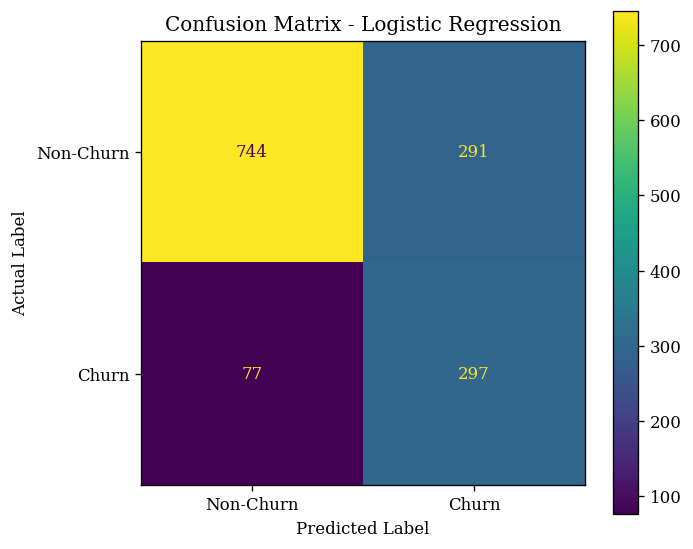

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\confusion_matrix_logreg.png


In [37]:
# ============================================================
# CELL 14: Confusion Matrix
# ============================================================

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Non-Churn", "Churn"],
    values_format="d",
    ax=ax
)

ax.set_title("Confusion Matrix - Logistic Regression")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

confusion_matrix_path = FIGURE_OUTPUT_DIR / "confusion_matrix_logreg.png"
plt.tight_layout()
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", confusion_matrix_path)

Cell 15 — ROC Curve figure

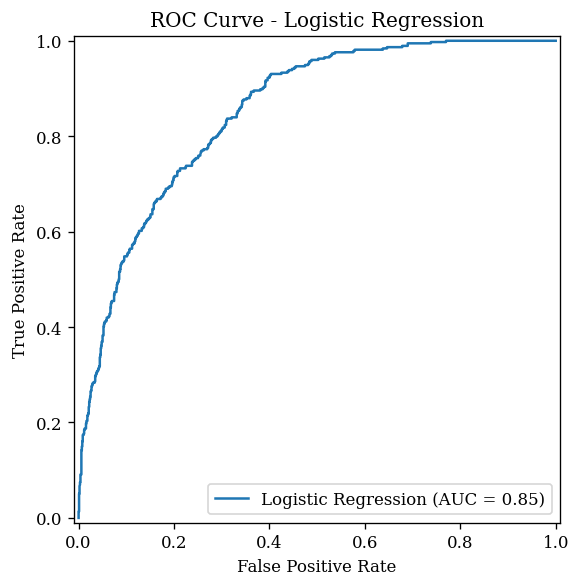

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\roc_curve_logreg.png


In [38]:
# ============================================================
# CELL 15: ROC Curve
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba,
    name="Logistic Regression",
    ax=ax
)

ax.set_title("ROC Curve - Logistic Regression")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

roc_curve_path = FIGURE_OUTPUT_DIR / "roc_curve_logreg.png"
plt.tight_layout()
plt.savefig(roc_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", roc_curve_path)

Cell 16 — Precision-Recall Curve figure

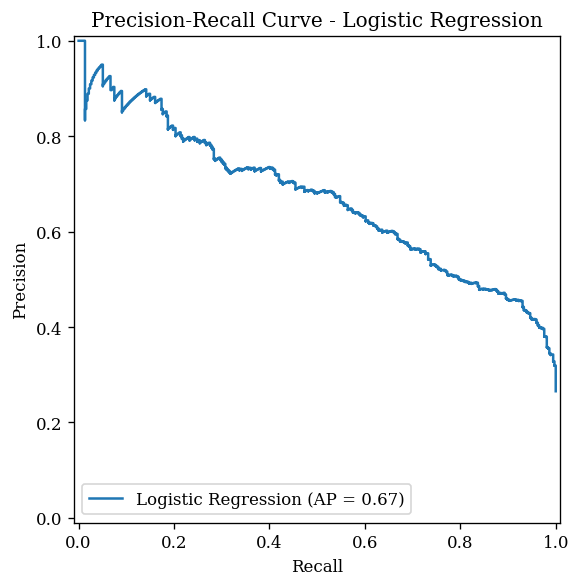

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\precision_recall_curve_logreg.png


In [39]:
# ============================================================
# CELL 16: Precision-Recall Curve
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_proba,
    name="Logistic Regression",
    ax=ax
)

ax.set_title("Precision-Recall Curve - Logistic Regression")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

pr_curve_path = FIGURE_OUTPUT_DIR / "precision_recall_curve_logreg.png"
plt.tight_layout()
plt.savefig(pr_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", pr_curve_path)

Cell 17 — Coefficient charts

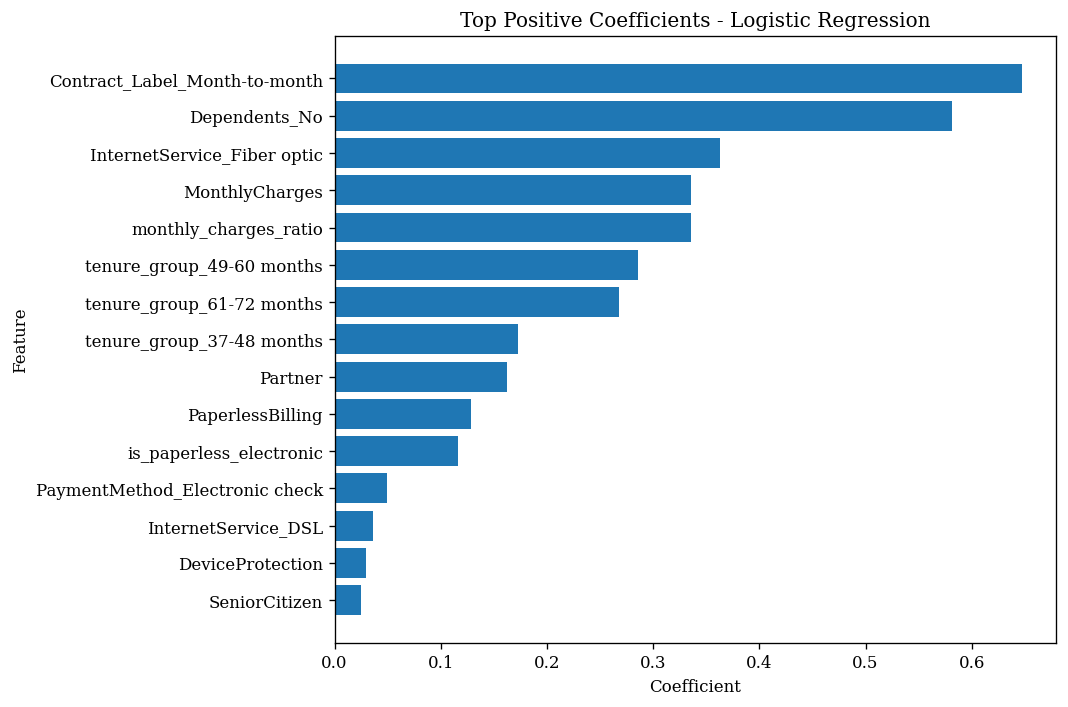

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\logreg_top_positive_coefficients.png


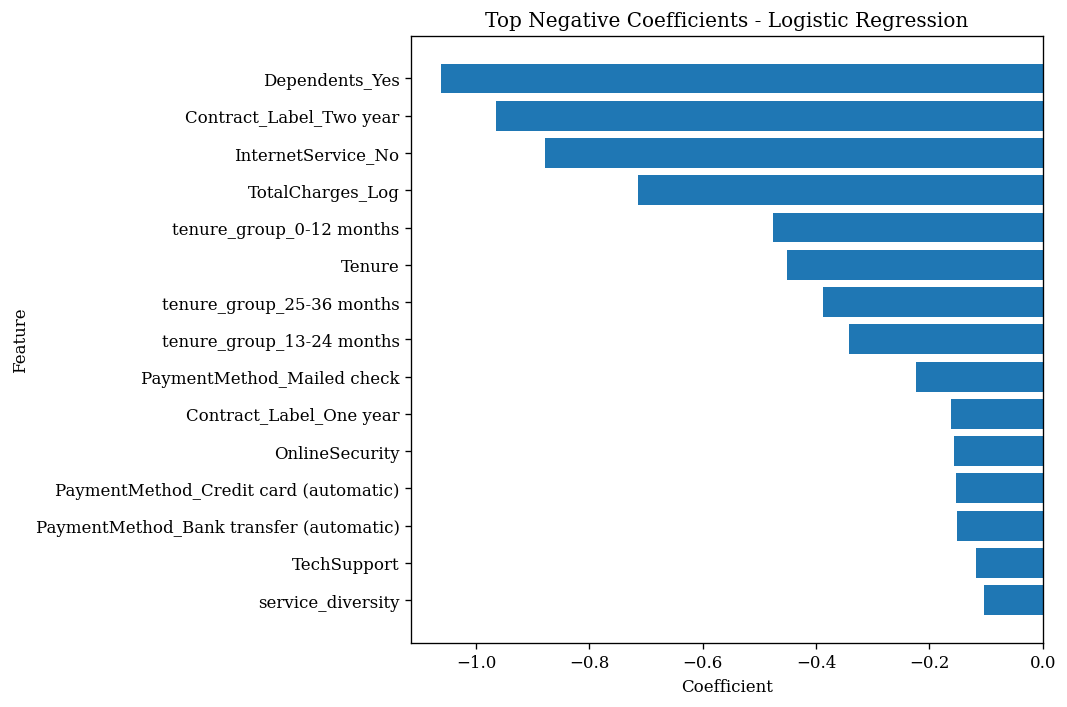

Saved: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\logreg_top_negative_coefficients.png


In [40]:
# ============================================================
# CELL 17: Coefficient charts
# ============================================================

top_positive = (
    logreg_coefficients_df
    .sort_values("coefficient", ascending=False)
    .head(15)
    .sort_values("coefficient", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(top_positive["feature"], top_positive["coefficient"])
ax.set_title("Top Positive Coefficients - Logistic Regression")
ax.set_xlabel("Coefficient")
ax.set_ylabel("Feature")

top_positive_path = FIGURE_OUTPUT_DIR / "logreg_top_positive_coefficients.png"
plt.tight_layout()
plt.savefig(top_positive_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", top_positive_path)


top_negative = (
    logreg_coefficients_df
    .sort_values("coefficient", ascending=True)
    .head(15)
    .sort_values("coefficient", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(top_negative["feature"], top_negative["coefficient"])
ax.set_title("Top Negative Coefficients - Logistic Regression")
ax.set_xlabel("Coefficient")
ax.set_ylabel("Feature")

top_negative_path = FIGURE_OUTPUT_DIR / "logreg_top_negative_coefficients.png"
plt.tight_layout()
plt.savefig(top_negative_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", top_negative_path)

Cell 18 — Final output summary

In [41]:
# ============================================================
# CELL 18: Final output summary
# ============================================================

print("LOGISTIC REGRESSION TRAINING COMPLETED")
print("=" * 60)

print("\nCSV outputs:")
print(logreg_metrics_path)
print(threshold_sensitivity_path)
print(logreg_predictions_path)
print(logreg_coefficients_path)

print("\nFigure outputs:")
print(confusion_matrix_path)
print(roc_curve_path)
print(pr_curve_path)
print(top_positive_path)
print(top_negative_path)

print("\nModel output:")
print(logreg_model_path)

print("\nMain metrics:")
print(logreg_metrics_df.to_string(index=False))

print("\nThreshold sensitivity:")
print(threshold_sensitivity_df.to_string(index=False))

print("\nTop 10 strongest coefficients:")
print(logreg_coefficients_df.head(10).to_string(index=False))

LOGISTIC REGRESSION TRAINING COMPLETED

CSV outputs:
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\logreg_metrics.csv
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\logreg_threshold_sensitivity.csv
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\logreg_test_predictions.csv
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\modeling\logreg_coefficients.csv

Figure outputs:
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\confusion_matrix_logreg.png
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\roc_curve_logreg.png
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\precision_recall_curve_logreg.png
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\logreg_top_positive_coefficients.png
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\modeling\logreg_top_negative_coefficients.png

Model output:
D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\m